# Part 2: Dimensionality Reduction & Feature Engineering
In this notebook, we prepare our RFM (Recency, Frequency, Monetary) data for clustering. 
Key steps include:
1. **Log Transformation**: To handle the high skewness typical of retail data.
2. **Standard Scaling**: To ensure all features have a mean of 0 and variance of 1.
3. **PCA (Principal Component Analysis)**: To analyze explained variance and reduce dimensions.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Add src to path for our plot saving utility
sys.path.append('../')
from src.utils import save_plot

# Aesthetics
%matplotlib inline
sns.set_style("white")

## 1. Load the Engineered RFM Data
We load the `rfm_data.csv` generated by our preprocessing pipeline in the previous notebook.

In [2]:
rfm_path = os.path.join('..', 'data', 'processed', 'rfm_data.csv')
rfm = pd.read_csv(rfm_path, index_col='Customer ID')

print(f"Data shape: {rfm.shape}")
rfm.head()

Data shape: (5878, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


## 2. Data Transformation (Log + Scaling)
Retail data usually follows a power-law distribution (a few customers spend a lot, 
most spend a little). We use a Log transform to "normalize" these distributions so 
distance-based algorithms like K-Means perform better.

Plot saved: ..\plots\dim_reduction\scaled_rfm_distributions.png


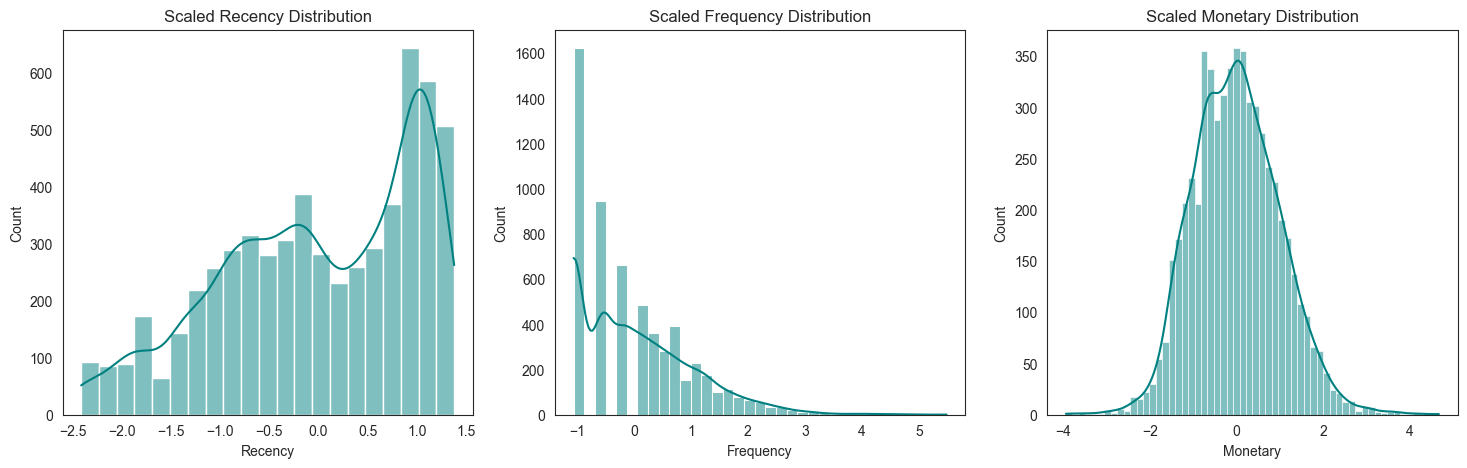

In [3]:
# 1. Handle Skewness with Log Transform
# We add 1 to avoid log(0) issues
rfm_log = np.log(rfm + 1)

# 2. Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Store in a DataFrame for easy handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

# Visualize the effect of scaling
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(rfm_scaled_df.columns):
    sns.histplot(rfm_scaled_df[col], kde=True, ax=ax[i], color='teal')
    ax[i].set_title(f'Scaled {col} Distribution')

save_plot('scaled_rfm_distributions.png', folder='dim_reduction')
plt.show()

## 3. PCA & Explained Variance Analysis
We apply PCA to see how much "information" (variance) is captured by each dimension. 
This helps us decide if we can represent our 3D RFM data in 2D without losing too 
much detail.

Plot saved: ..\plots\dim_reduction\pca_variance_plot.png


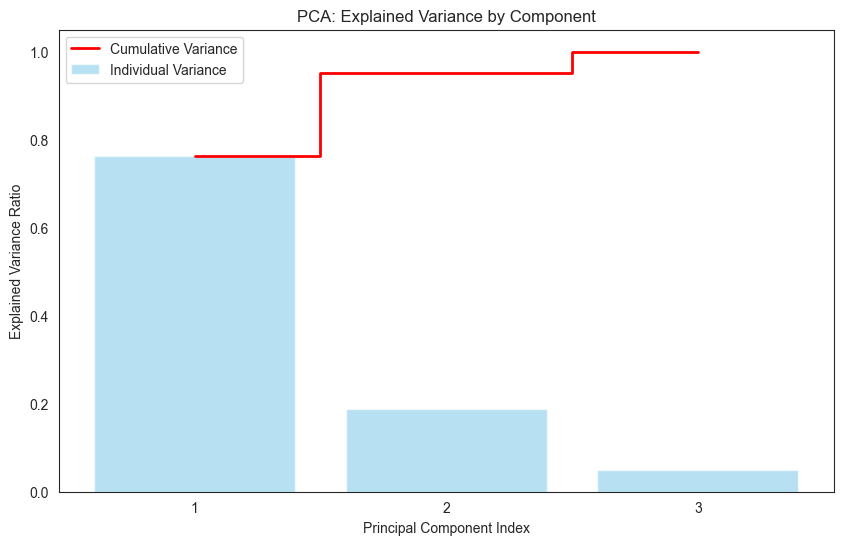

Total Variance Explained by PC1 & PC2: 95.14%


In [4]:
# Initialize PCA for all 3 components
pca = PCA(n_components=3)
pca_weights = pca.fit_transform(rfm_scaled)

# Calculate variance metrics
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Plotting Explained Variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, 4), exp_var, alpha=0.6, align='center', 
        label='Individual Variance', color='skyblue')
plt.step(range(1, 4), cum_var, where='mid', 
         label='Cumulative Variance', color='red', lw=2)

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA: Explained Variance by Component')
plt.xticks([1, 2, 3])
plt.legend(loc='best')

save_plot('pca_variance_plot.png', folder='dim_reduction')
plt.show()

print(f"Total Variance Explained by PC1 & PC2: {cum_var[1]:.2%}")

## 4. Exporting Data for Clustering
We will save both the **scaled RFM data** and the **PCA components**. 
We'll use these in the next notebook to run K-Means and DBSCAN.

In [5]:
# Save the scaled data
scaled_path = os.path.join('..', 'data', 'processed', 'rfm_scaled.csv')
rfm_scaled_df.to_csv(scaled_path)

# Save the PCA weights (we'll use PC1 and PC2 for 2D visualization later)
pca_df = pd.DataFrame(pca_weights, columns=['PC1', 'PC2', 'PC3'], index=rfm.index)
pca_path = os.path.join('..', 'data', 'processed', 'rfm_pca.csv')
pca_df.to_csv(pca_path)

print(f"Success! Files saved to {os.path.dirname(scaled_path)}")

Success! Files saved to ..\data\processed
